In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.cluster import KMeans

In [41]:
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path direktori dataset:", path)

print("Daftar file:", os.listdir(path))

file_path = os.path.join(path, "Mall_Customers.csv")

dataset = pd.read_csv(file_path)

dataset.head()

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path direktori dataset: /kaggle/input/customer-segmentation-tutorial-in-python
Daftar file: ['Mall_Customers.csv']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [42]:
X = dataset.iloc[:, 3:5]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [43]:
X.shape

(200, 2)

In [44]:
X.isnull().sum()

,0
Annual Income (k$),0
Spending Score (1-100),0


In [45]:
X.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


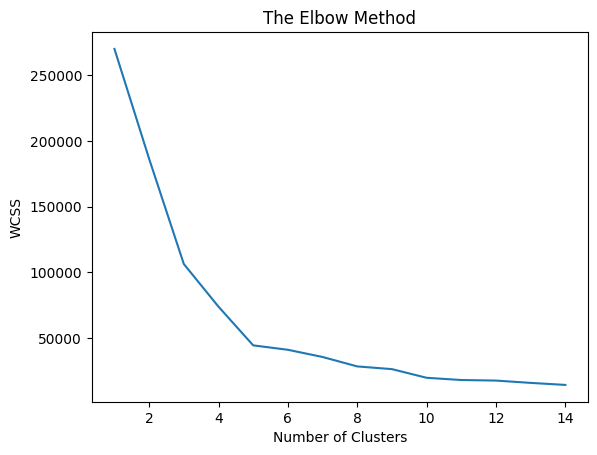

In [46]:
wcss = []

for i in range (1, 15):
  kmeans = KMeans(n_clusters = i, random_state =14)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

plt.plot(range(1, 15), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [47]:
kmeans = KMeans(n_clusters = 5, random_state =14)
kmeans.fit(X)

KMeans(n_clusters=5, random_state=14)

In [49]:
kmeans.labels_

array([2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 0,
       2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 4, 0, 4, 1, 4, 1, 4,
       0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4], dtype=int32)

In [50]:
MYresult_kmeans = X.copy()
MYresult_kmeans["cluster"] = kmeans.labels_
MYresult_kmeans.head()

,Annual Income (k$),Spending Score (1-100),cluster
0,15,39,2
1,15,81,3
2,16,6,2
3,16,77,3
4,17,40,2


Text(0, 0.5, 'Frekuensi')

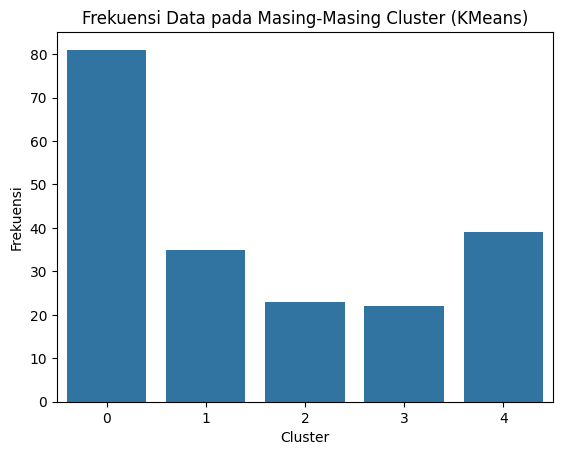

In [53]:
cluster_x = MYresult_kmeans["cluster"].value_counts().index
cluster_y = MYresult_kmeans["cluster"].value_counts().values

sns.barplot(x=cluster_x, y=cluster_y)
plt.title("Frekuensi Data pada Masing-Masing Cluster (KMeans)")
plt.xlabel("Cluster")
plt.ylabel("Frekuensi")

In [59]:
MYresult_kmeans["CustomerID"] = dataset["CustomerID"]
MYresult_kmeans.head()

,Annual Income (k$),Spending Score (1-100),cluster,CustomerID
0,15,39,2,1
1,15,81,3,2
2,16,6,2,3
3,16,77,3,4
4,17,40,2,5


In [60]:
MYresult_kmeans.to_csv("Hasil Clustering Menggunakan K-Means.csv", index = False)